# Theory of Mind LLM Test - Figure Generation

This notebook generates figures from the preprocessed data, similar to Figure 1 from the original R analysis.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'

## Load and Prepare Data

In [21]:
# Load preprocessed data
df = pd.read_csv('data/preprocessed.txt')

# Display first few rows
print("Data shape:", df.shape)
print("\nFirst few rows:")
df.head()

Data shape: (851, 6)

First few rows:


,Unnamed: 0,task,trial,source,model,score
0,1,False Belief,score1,New,GPT-3.5,0.8
1,2,False Belief,score1,New,GPT-4,0.6
2,3,False Belief,score1,New,Human,0.6
3,4,False Belief,score1,New,LLaMA2-70B,0.8
4,5,False Belief,score1,Original,GPT-3.5,1.0


In [22]:
# Check unique values
print("Tasks:", df['task'].unique())
print("\nModels:", df['model'].unique())
print("\nSources:", df['source'].unique())

Tasks: ['False Belief' 'Faux Pas' 'Hinting' 'Irony' 'Strange Stories']

Models: ['GPT-3.5' 'GPT-4' 'Human' 'LLaMA2-70B']

Sources: ['New' 'Original']


## Define Color Palette and Settings

In [23]:
# Color palette matching the original R code
colors = {
    'Human': '#9158b5',
    'GPT-4': '#115f9a',
    'GPT-3.5': '#48b5c4',
    'LLaMA2-70B': '#43b768'
}

# Model order
model_order = ['Human', 'GPT-4', 'GPT-3.5', 'LLaMA2-70B']

# Ensure proper factor ordering
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

## Calculate Summary Statistics by Task

In [24]:
# Calculate mean scores by task and model for ordering tasks
task_means = df[df['source'] == 'Original'].groupby(['task', 'model'])['score'].mean().reset_index()
human_task_means = task_means[task_means['model'] == 'Human'].sort_values('score', ascending=False)
task_order = human_task_means['task'].tolist()

print("Task order (by human performance):")
for i, task in enumerate(task_order, 1):
    mean_score = human_task_means[human_task_means['task'] == task]['score'].values[0]
    print(f"{i}. {task}: {mean_score:.3f}")

# Set task order
df['task'] = pd.Categorical(df['task'], categories=task_order, ordered=True)

Task order (by human performance):
1. False Belief: 1.000
2. Irony: 0.942
3. Faux Pas: 0.851
4. Hinting: 0.840
5. Strange Stories: 0.828


## Statistical Testing: LLMs vs Human Baseline

In [25]:
# Perform Wilcoxon (Mann-Whitney U) tests comparing each model to humans
# Filter to original items only
df_original = df[df['source'] == 'Original'].copy()

# Store comparison results
comparisons = []

for task in task_order:
    if task == 'False Belief':
        # Skip False Belief due to ceiling effects
        continue
    
    task_data = df_original[df_original['task'] == task]
    human_scores = task_data[task_data['model'] == 'Human']['score'].values
    
    for model in ['GPT-4', 'GPT-3.5', 'LLaMA2-70B']:
        model_scores = task_data[task_data['model'] == model]['score'].values
        
        if len(model_scores) > 0 and len(human_scores) > 0:
            statistic, p_value = mannwhitneyu(human_scores, model_scores, alternative='two-sided')
            comparisons.append({
                'task': task,
                'model': model,
                'statistic': statistic,
                'p_value': p_value,
                'human_mean': human_scores.mean(),
                'model_mean': model_scores.mean()
            })

comp_df = pd.DataFrame(comparisons)

# Apply Holm correction for multiple comparisons
from statsmodels.stats.multitest import multipletests
if len(comp_df) > 0:
    _, p_adj, _, _ = multipletests(comp_df['p_value'], method='holm')
    comp_df['p_adj'] = p_adj
    comp_df['significance'] = comp_df['p_adj'].apply(
        lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    )

print("\nStatistical Comparisons (LLMs vs Human):")
print(comp_df[['task', 'model', 'human_mean', 'model_mean', 'p_value', 'p_adj', 'significance']].to_string(index=False))


Statistical Comparisons (LLMs vs Human):
           task      model  human_mean  model_mean      p_value        p_adj significance
          Irony      GPT-4    0.941667    0.988889 1.031158e-02 4.124632e-02            *
          Irony    GPT-3.5    0.941667    0.788889 2.369746e-07 2.369746e-06          ***
          Irony LLaMA2-70B    0.941667    0.600000 2.173280e-08 2.390609e-07          ***
       Faux Pas      GPT-4    0.850980    0.493333 6.781199e-06 5.424959e-05          ***
       Faux Pas    GPT-3.5    0.850980    0.120000 4.959669e-09 5.951603e-08          ***
       Faux Pas LLaMA2-70B    0.850980    0.953333 3.262439e-04 1.957463e-03           **
        Hinting      GPT-4    0.839583    0.933333 1.062125e-02 4.124632e-02            *
        Hinting    GPT-3.5    0.839583    0.873333 6.257163e-01 6.257163e-01             
        Hinting LLaMA2-70B    0.839583    0.653333 7.279664e-06 5.424959e-05          ***
Strange Stories      GPT-4    0.827500    0.995833 1.15959

## Figure 1A: Violin Plot (Original Items)

In [ ]:
# Create violin plot similar to Figure 1A
fig, ax = plt.subplots(figsize=(12, 6))

# Filter to original items
plot_data = df_original.copy()

# Create positions for models within each task
dodge_spacing = 0.7
sig_spacing = 0.05

# Plot using seaborn
for i, task in enumerate(task_order):
    task_data = plot_data[plot_data['task'] == task]
    
    for j, model in enumerate(model_order):
        model_data = task_data[task_data['model'] == model]
        if len(model_data) == 0:
            continue
        
        # Calculate position
        pos = i + (j - 1.5) * dodge_spacing / 4
        
        # Get scores
        scores = model_data['score'].values
        
        # Plot violin
        parts = ax.violinplot([scores], positions=[pos], widths=dodge_spacing/4,
                              showmeans=False, showmedians=False, showextrema=False)
        
        for pc in parts['bodies']:
            pc.set_facecolor(colors[model])
            pc.set_alpha(0.5)
            pc.set_edgecolor(colors[model])
        
        # Plot individual points
        jitter = np.random.normal(0, 0.02, size=len(scores))
        ax.scatter([pos + j for j in jitter], scores, 
                  color=colors[model], alpha=0.6, s=20, zorder=3)
        
        # Plot median as black dot
        ax.scatter([pos], [np.median(scores)], 
                  color='black', s=50, zorder=4, marker='o')

# Add p-values and significance markers
# Group by task to calculate proper spacing
for i, task in enumerate(task_order):
    if task == 'False Belief':
        continue

    task_comps = comp_df[comp_df['task'] == task]

    # Calculate the starting y position for this task's p-values
    # Use different heights for different models to avoid overlap
    y_start = 1.02

    # Add p-values at the top for each model
    for model_idx_in_task, (_, row) in enumerate(task_comps.iterrows()):
        model = row['model']
        model_idx = model_order.index(model)

        # Position x based on model position within task
        pos = i + (model_idx - 1.5) * dodge_spacing / 4

        # Stagger y positions by model to prevent overlap
        # Each model gets its own row
        y_pos = y_start + model_idx_in_task * 0.06

        # Format p-value for display
        p_val = row['p_adj']
        if p_val < 0.001:
            p_str = f"{p_val:.2e}".replace('e-0', ' × 10⁻').replace('e-', ' × 10⁻')
        else:
            p_str = f"{p_val:.3f}"

        # Add horizontal line from baseline to model position
        line_start = i - 3*dodge_spacing/8
        line_end = pos
        ax.plot([line_start, line_end], [y_pos, y_pos], 'k-', linewidth=0.5)

        # Add p-value text above the line
        ax.text(pos, y_pos + 0.005, p_str,
               ha='center', va='bottom', fontsize=6.5, rotation=0)

        # Add significance marker if significant
        if row['significance']:
            ax.text(pos, y_pos - 0.01, row['significance'],
                   ha='center', va='top', fontsize=8, fontweight='bold')

# Formatting
ax.set_xticks(range(len(task_order)))
ax.set_xticklabels(task_order, rotation=0, ha='center')
ax.set_ylabel('Response score (fraction correct)')
ax.set_xlabel('Task')
# Increase ylim to accommodate all p-values (3 models × 0.06 spacing)
ax.set_ylim(0, 1.25)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[model], label=model, alpha=0.7) 
                  for model in model_order]
ax.legend(handles=legend_elements, loc='upper right', ncol=4, frameon=True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/figure1a_violin.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure 1A saved to figures/figure1a_violin.png")

## Statistical Testing: Original vs New Items

In [27]:
# Compare original vs new items for each model and task
# Exclude Irony (no new items) and False Belief (ceiling)
source_comparisons = []

for task in task_order:
    if task in ['Irony', 'False Belief']:
        continue
    
    task_data = df[df['task'] == task]
    
    for model in model_order:
        model_data = task_data[task_data['model'] == model]
        original_scores = model_data[model_data['source'] == 'Original']['score'].values
        new_scores = model_data[model_data['source'] == 'New']['score'].values
        
        if len(original_scores) > 0 and len(new_scores) > 0:
            statistic, p_value = mannwhitneyu(original_scores, new_scores, alternative='two-sided')
            source_comparisons.append({
                'task': task,
                'model': model,
                'original_mean': original_scores.mean(),
                'new_mean': new_scores.mean(),
                'p_value': p_value
            })

source_comp_df = pd.DataFrame(source_comparisons)

# Apply Holm correction
if len(source_comp_df) > 0:
    _, p_adj, _, _ = multipletests(source_comp_df['p_value'], method='holm')
    source_comp_df['p_adj'] = p_adj
    source_comp_df['significance'] = source_comp_df['p_adj'].apply(
        lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    )

print("\nStatistical Comparisons (Original vs New Items):")
print(source_comp_df[['task', 'model', 'original_mean', 'new_mean', 'p_adj', 'significance']].to_string(index=False))


Statistical Comparisons (Original vs New Items):
           task      model  original_mean  new_mean    p_adj significance
       Faux Pas      Human       0.850980  0.909804 0.028491            *
       Faux Pas      GPT-4       0.493333  0.306667 0.461768             
       Faux Pas    GPT-3.5       0.120000  0.000000 0.002086           **
       Faux Pas LLaMA2-70B       0.953333  0.933333 1.000000             
        Hinting      Human       0.839583  0.920139 0.008154           **
        Hinting      GPT-4       0.933333  0.977778 0.122924             
        Hinting    GPT-3.5       0.873333  0.922222 0.955424             
        Hinting LLaMA2-70B       0.653333  0.877778 0.000918          ***
Strange Stories      Human       0.827500  0.822500 1.000000             
Strange Stories      GPT-4       0.995833  1.000000 1.000000             
Strange Stories    GPT-3.5       0.775000  0.866667 0.085551             
Strange Stories LLaMA2-70B       0.725000  0.741667 0.955424  

## Figure 1B: Barbell Plot (Original vs New)

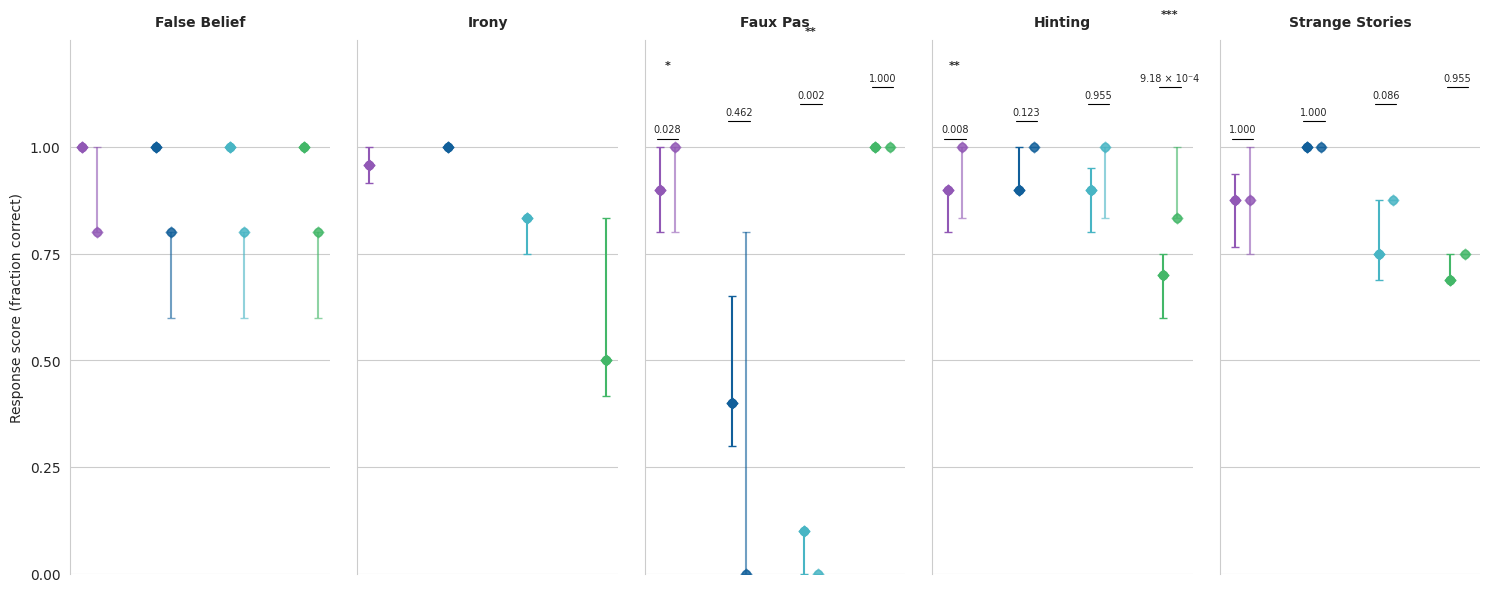


Figure 1B saved to figures/figure1b_barbell.png


In [28]:
# Calculate quartiles for barbell plot
barbell_data = []

for task in task_order:
    for model in model_order:
        for source in ['Original', 'New']:
            subset = df[(df['task'] == task) & 
                       (df['model'] == model) & 
                       (df['source'] == source)]
            
            if len(subset) > 0:
                scores = subset['score'].values
                barbell_data.append({
                    'task': task,
                    'model': model,
                    'source': source,
                    'q1': np.percentile(scores, 25),
                    'median': np.median(scores),
                    'q3': np.percentile(scores, 75)
                })

barbell_df = pd.DataFrame(barbell_data)

# Create barbell plot
fig, axes = plt.subplots(1, len(task_order), figsize=(15, 6), sharey=True)

for idx, task in enumerate(task_order):
    ax = axes[idx]
    task_data = barbell_df[barbell_df['task'] == task]

    # Plot for each model
    for i, model in enumerate(model_order):
        model_data = task_data[task_data['model'] == model]

        if len(model_data) == 0:
            continue

        # Get original and new data
        original = model_data[model_data['source'] == 'Original']
        new = model_data[model_data['source'] == 'New']

        pos = i

        # Plot original (darker color)
        if len(original) > 0:
            orig_row = original.iloc[0]
            ax.errorbar([pos - 0.1], [orig_row['median']],
                       yerr=[[orig_row['median'] - orig_row['q1']],
                             [orig_row['q3'] - orig_row['median']]],
                       fmt='o', color=colors[model], markersize=6,
                       capsize=3, linewidth=1.5, label=f"{model} (Original)" if idx == 0 else "")
            # Add diamond for median
            ax.scatter([pos - 0.1], [orig_row['median']],
                      marker='D', s=30, color=colors[model], zorder=5)

        # Plot new (lighter color)
        if len(new) > 0:
            new_row = new.iloc[0]
            light_color = colors[model] + '80'  # Add transparency
            ax.errorbar([pos + 0.1], [new_row['median']],
                       yerr=[[new_row['median'] - new_row['q1']],
                             [new_row['q3'] - new_row['median']]],
                       fmt='o', color=light_color, markersize=6,
                       capsize=3, linewidth=1.5, alpha=0.6,
                       label=f"{model} (New)" if idx == 0 else "")
            # Add diamond for median
            ax.scatter([pos + 0.1], [new_row['median']],
                      marker='D', s=30, color=light_color, alpha=0.6, zorder=5)

    # Add p-values at the top of each panel
    # Get max y value for this task
    task_max_y = task_data[['q3']].max().values[0]
    y_text_pos = max(task_max_y + 0.02, 1.0)

    # Add horizontal line showing p-values for each comparison
    task_sig = source_comp_df[source_comp_df['task'] == task]

    # Get p-values for each model comparison at this task
    p_values_display = []
    for model in model_order:
        model_sig = task_sig[task_sig['model'] == model]
        if len(model_sig) > 0:
            p_val = model_sig['p_adj'].values[0]
            # Format p-value for display
            if p_val < 0.001:
                p_str = f"{p_val:.2e}".replace('e-0', ' × 10⁻')
            elif p_val < 0.01:
                p_str = f"{p_val:.3f}"
            else:
                p_str = f"{p_val:.3f}"
            p_values_display.append((model, p_val, p_str))

    # Draw lines and p-values
    if len(p_values_display) > 0:
        # Find the position for p-value labels
        y_line_pos = 1.02

        for model, p_val, p_str in p_values_display:
            model_idx = model_order.index(model)

            # Draw horizontal line
            line_y = y_line_pos + model_idx * 0.04
            ax.plot([model_idx - 0.15, model_idx + 0.15], [line_y, line_y],
                   'k-', linewidth=0.8)

            # Add p-value text
            ax.text(model_idx, line_y + 0.01, p_str,
                   ha='center', va='bottom', fontsize=7)

    # Add significance markers
    for _, row in task_sig.iterrows():
        if row['significance']:
            model_idx = model_order.index(row['model'])
            sig_y = 1.18 + model_idx * 0.04
            ax.text(model_idx, sig_y, row['significance'],
                   ha='center', va='bottom', fontsize=8, fontweight='bold')

    # Formatting
    ax.set_xticks([])
    ax.set_title(task, fontsize=10, fontweight='bold', pad=10)
    ax.set_ylim(0, 1.25)  # Extended to accommodate p-values
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    if idx == 0:
        ax.set_ylabel('Response score (fraction correct)')
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

plt.tight_layout()
plt.savefig('figures/figure1b_barbell.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure 1B saved to figures/figure1b_barbell.png")

## Summary Statistics Table

In [29]:
# Create summary table
summary = df_original.groupby(['task', 'model'])['score'].agg(['mean', 'std', 'count']).reset_index()
summary['mean'] = summary['mean'].round(3)
summary['std'] = summary['std'].round(3)

print("\nSummary Statistics (Original Items):")
print(summary.pivot(index='task', columns='model', values='mean').to_string())


Summary Statistics (Original Items):
model            Human  GPT-4  GPT-3.5  LLaMA2-70B
task                                              
False Belief     1.000  1.000    1.000       1.000
Irony            0.942  0.989    0.789       0.600
Faux Pas         0.851  0.493    0.120       0.953
Hinting          0.840  0.933    0.873       0.653
Strange Stories  0.828  0.996    0.775       0.725
